In [2]:
#Análise de Criptomoedas com API Real

'''1️⃣ Contexto do Problema

Você trabalha em uma fintech que acompanha o mercado de criptomoedas.

O time de produto quer entender:

quais criptomoedas estão no top ranking

quais possuem maior volume de negociação

como está a evolução de preço

Para isso você irá consumir uma API pública de criptomoedas.

2️⃣ API Real

Vamos usar a API pública da CoinGecko.

Endpoint:

https://api.coingecko.com/api/v3/coins/markets

Parâmetros:

vs_currency=usd
order=market_cap_desc
per_page=20
page=1
sparkline=false

URL completa:

https://api.coingecko.com/api/v3/coins/markets?vs_currency=usd&order=market_cap_desc&per_page=20&page=1&sparkline=false

Essa API retorna dados como:

nome da moeda

preço atual

market cap

volume de negociação

ranking

3️⃣ Objetivo do Pipeline

Você irá construir um pipeline simples:

API CoinGecko
      ↓
JSON
      ↓
DataFrame pandas
      ↓
transformação
      ↓
análise
      ↓
visualização


4️⃣ Dataset (campos importantes)

A API retorna muitos campos, mas foque em:

id
symbol
name
current_price
market_cap
market_cap_rank
total_volume
price_change_percentage_24h
5️⃣ Tarefas do Projeto
Parte 1 — Consumir a API

Usar Python para buscar os dados da API.

Transformar o retorno em JSON.

Parte 2 — Criar DataFrame

Transformar os dados da API em um DataFrame pandas.

Explorar com:

df.head()
df.info()
df.describe()
Parte 3 — Limpeza de dados

Selecionar apenas colunas importantes.

Exemplo esperado no dataset final:

name
symbol
current_price
market_cap
market_cap_rank
total_volume
price_change_percentage_24h
Parte 4 — Análises

Responder com código:

1️⃣ Top 10 criptomoedas por market cap
2️⃣ Top 10 por volume de negociação
3️⃣ Criptomoedas com maior valorização nas últimas 24h

Ordenar por:

price_change_percentage_24h
4️⃣ Preço médio das criptomoedas analisadas
6️⃣ Visualizações

Criar pelo menos 3 gráficos.

1️⃣ Top 10 criptomoedas por market cap

Sugestão:

bar chart
2️⃣ Top 10 por volume
3️⃣ Variação percentual nas últimas 24h

Pode usar:

bar chart

ou

horizontal bar chart'''

'1️⃣ Contexto do Problema\n\nVocê trabalha em uma fintech que acompanha o mercado de criptomoedas.\n\nO time de produto quer entender:\n\nquais criptomoedas estão no top ranking\n\nquais possuem maior volume de negociação\n\ncomo está a evolução de preço\n\nPara isso você irá consumir uma API pública de criptomoedas.\n\n2️⃣ API Real\n\nVamos usar a API pública da CoinGecko.\n\nEndpoint:\n\nhttps://api.coingecko.com/api/v3/coins/markets\n\nParâmetros:\n\nvs_currency=usd\norder=market_cap_desc\nper_page=20\npage=1\nsparkline=false\n\nURL completa:\n\nhttps://api.coingecko.com/api/v3/coins/markets?vs_currency=usd&order=market_cap_desc&per_page=20&page=1&sparkline=false\n\nEssa API retorna dados como:\n\nnome da moeda\n\npreço atual\n\nmarket cap\n\nvolume de negociação\n\nranking\n\n3️⃣ Objetivo do Pipeline\n\nVocê irá construir um pipeline simples:\n\nAPI CoinGecko\n      ↓\nJSON\n      ↓\nDataFrame pandas\n      ↓\ntransformação\n      ↓\nanálise\n      ↓\nvisualização\n\n\n4️⃣ Dataset 

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
def consumir_api ():
    #configuração do end-point
    url= "https://api.coingecko.com/api/v3/coins/markets"
    #parametros da requisição
    params={
            'vs_currency':'usd',
            'order':'market_cap_desc',
            'per_page':20,
            'page':1,
            'sparkline':'false'
    }
    try: 
        #chamar a api
        response=requests.get(url,params=params)
        #verificar se a requisição deu certo
        response.raise_for_status()
        #converter o json para uma lista/dict
        dados=response.json()
    except Exception as error:
        print(f"Erro: {error}")
    df=pd.DataFrame(dados)
    return df
consumir_api()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,71652.000000,1433683262389,1,1433683262389,21724256392,71893.000000,...,2.000249e+07,2.100000e+07,126080.000000,-43.16952,2025-10-06T18:57:42.558Z,67.810000,1.055671e+05,2013-07-06T00:00:00.000Z,None,2026-03-15T20:35:00.694Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2123.850000,256389397164,2,256389397164,9232414642,2123.860000,...,1.206919e+08,NaN,4946.050000,-57.05961,2025-08-24T19:21:03.333Z,0.432979,4.904210e+05,2015-10-20T00:00:00.000Z,"{'times': 38.62080387983195, 'currency': 'btc'...",2026-03-15T20:35:00.946Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.000000,184058152567,3,189525858745,39705848459,1.001000,...,1.894993e+11,NaN,1.320000,-24.41148,2018-07-24T00:00:00.000Z,0.572521,7.468498e+01,2015-03-02T00:00:00.000Z,None,2026-03-15T20:34:51.392Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,662.950000,90398539180,4,90398539180,564270512,665.960000,...,1.363580e+08,2.000000e+08,1369.990000,-51.60948,2025-10-13T08:41:24.131Z,0.039818,1.664853e+06,2017-10-19T00:00:00.000Z,None,2026-03-15T20:35:00.360Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.420000,86658864163,5,141514847093,1566495287,1.430000,...,9.998570e+10,1.000000e+11,3.650000,-61.18531,2025-07-18T03:40:53.808Z,0.002686,5.258881e+04,2014-05-22T00:00:00.000Z,None,2026-03-15T20:34:53.154Z
5,usd-coin,usdc,USDC,https://coin-images.coingecko.com/coins/images...,0.999903,79146473280,6,79146566057,2137690961,1.000000,...,7.915424e+10,NaN,1.043000,-4.16541,2018-11-15T00:00:00.000Z,0.877647,1.394108e+01,2023-03-11T08:02:13.981Z,None,2026-03-15T20:34:51.747Z
6,solana,sol,Solana,https://coin-images.coingecko.com/coins/images...,88.300000,50453010734,7,50453013849,2046659561,88.770000,...,5.713559e+08,NaN,293.310000,-69.89398,2025-01-19T11:15:27.957Z,0.500801,1.753265e+04,2020-05-11T19:35:23.449Z,None,2026-03-15T20:34:57.675Z
7,tron,trx,TRON,https://coin-images.coingecko.com/coins/images...,0.298526,28285155289,8,28285210857,343508834,0.299089,...,9.475003e+10,NaN,0.431288,-30.78270,2024-12-04T00:10:40.323Z,0.001804,1.644488e+04,2017-11-12T00:00:00.000Z,"{'times': 156.11902948374328, 'currency': 'usd...",2026-03-15T20:35:02.961Z
8,figure-heloc,figr_heloc,Figure Heloc,https://coin-images.coingecko.com/coins/images...,1.003000,15891025852,9,15891025852,8050374,1.003000,...,1.584731e+10,NaN,1.049000,-4.41894,2026-03-09T17:00:25.937Z,0.155357,5.454561e+02,2025-10-31T14:27:24.456Z,None,2026-03-15T02:18:49.457Z
9,dogecoin,doge,Dogecoin,https://coin-images.coingecko.com/coins/images...,0.095214,14605267483,10,16100925346,821679685,0.097094,...,1.691351e+11,NaN,0.731578,-86.98508,2021-05-08T05:08:23.458Z,0.000087,1.094629e+05,2015-05-06T00:00:00.000Z,None,2026-03-15T20:35:02.712Z


In [4]:
df_crypto= consumir_api()
df_crypto.head()


,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,71652.00,1433683262389,1,1433683262389,21724256392,71893.000,...,2.000249e+07,2.100000e+07,126080.00,-43.16952,2025-10-06T18:57:42.558Z,67.810000,1.055671e+05,2013-07-06T00:00:00.000Z,None,2026-03-15T20:35:00.694Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2123.85,256389397164,2,256389397164,9232414642,2123.860,...,1.206919e+08,NaN,4946.05,-57.05961,2025-08-24T19:21:03.333Z,0.432979,4.904210e+05,2015-10-20T00:00:00.000Z,"{'times': 38.62080387983195, 'currency': 'btc'...",2026-03-15T20:35:00.946Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.00,184058152567,3,189525858745,39705848459,1.001,...,1.894993e+11,NaN,1.32,-24.41148,2018-07-24T00:00:00.000Z,0.572521,7.468498e+01,2015-03-02T00:00:00.000Z,None,2026-03-15T20:34:51.392Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,662.95,90398539180,4,90398539180,564270512,665.960,...,1.363580e+08,2.000000e+08,1369.99,-51.60948,2025-10-13T08:41:24.131Z,0.039818,1.664853e+06,2017-10-19T00:00:00.000Z,None,2026-03-15T20:35:00.360Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.42,86658864163,5,141514847093,1566495287,1.430,...,9.998570e+10,1.000000e+11,3.65,-61.18531,2025-07-18T03:40:53.808Z,0.002686,5.258881e+04,2014-05-22T00:00:00.000Z,None,2026-03-15T20:34:53.154Z


In [5]:
df=df_crypto.filter(items=['id',
'symbol',
'name',
'current_price',
'market_cap',
'market_cap_rank',
'total_volume',
'price_change_percentage_24h'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           20 non-null     str    
 1   symbol                       20 non-null     str    
 2   name                         20 non-null     str    
 3   current_price                20 non-null     float64
 4   market_cap                   20 non-null     int64  
 5   market_cap_rank              20 non-null     int64  
 6   total_volume                 20 non-null     int64  
 7   price_change_percentage_24h  20 non-null     float64
dtypes: float64(2), int64(3), str(3)
memory usage: 1.8 KB


In [6]:
df_crypto.isnull().sum()
df_crypto.dropna()
df.describe()

,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h
count,20.000000,2.000000e+01,20.00000,2.000000e+01,20.000000
mean,3773.083010,1.161809e+11,10.50000,3.966768e+09,0.536070
std,15984.511241,3.171923e+11,5.91608,9.818375e+09,1.072443
min,0.095214,5.713875e+09,1.00000,7.304270e+05,-2.142680
25%,0.999896,8.707439e+09,5.75000,6.060855e+07,-0.041890
50%,5.240000,1.328515e+10,10.50000,2.885254e+08,0.234985
75%,154.777500,8.102457e+10,15.25000,1.686536e+09,1.437418
max,71652.000000,1.433683e+12,20.00000,3.970585e+10,2.112900


In [7]:
df.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h
0,bitcoin,btc,Bitcoin,71652.00,1433683262389,1,21724256392,1.25233
1,ethereum,eth,Ethereum,2123.85,256389397164,2,9232414642,2.09221
2,tether,usdt,Tether,1.00,184058152567,3,39705848459,0.00493
3,binancecoin,bnb,BNB,662.95,90398539180,4,564270512,1.39498
4,ripple,xrp,XRP,1.42,86658864163,5,1566495287,1.67232


In [8]:
#top 10 cap
top_cap=df.groupby('symbol')['market_cap'].sum().nlargest(10)
print(top_cap)

symbol
btc           1433683262389
eth            256389397164
usdt           184058152567
bnb             90398539180
xrp             86658864163
usdc            79146473280
sol             50453010734
trx             28285155289
figr_heloc      15891025852
doge            14605267483
Name: market_cap, dtype: int64


In [9]:
#top 10 vol
top_vol= df.groupby('symbol')['total_volume'].sum().nlargest(10)
print(top_vol)

symbol
usdt    39705848459
btc     21724256392
eth      9232414642
usdc     2137690961
sol      2046659561
xrp      1566495287
doge      821679685
bnb       564270512
trx       343508834
ada       307657326
Name: total_volume, dtype: int64


In [10]:
#maior valorização 24h
change_hight=df.sort_values(by='price_change_percentage_24h', ascending=False).head(1)
print(change_hight)

           id symbol       name  current_price  market_cap  market_cap_rank  \
17  chainlink   link  Chainlink           9.22  6522756940               18   

    total_volume  price_change_percentage_24h  
17     269393475                       2.1129  


In [11]:
#preço médio
avg_price= df['current_price'].mean()
print(f'o preço médio de todas cryptos é de {avg_price}')

o preço médio de todas cryptos é de 3773.08300955


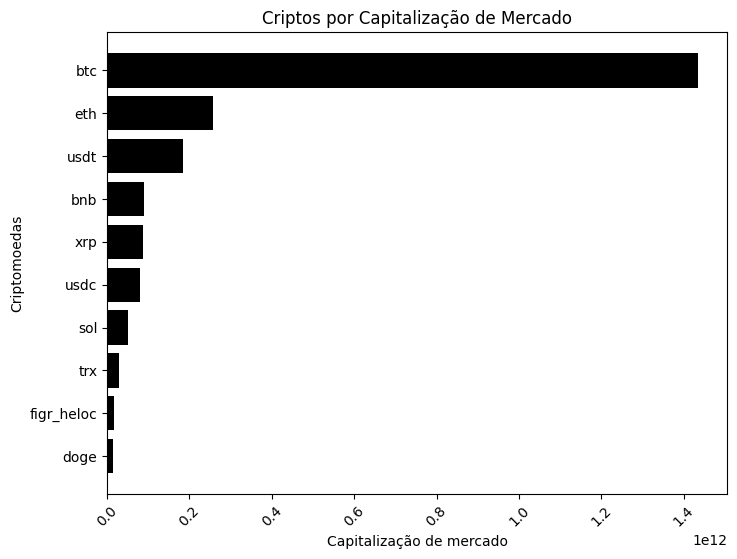

In [12]:
#vizualizações
plt.figure(figsize=(8,6))
plt.barh(top_cap.index,top_cap.values, color='black')
plt.gca().invert_yaxis()
plt.title('Criptos por Capitalização de Mercado')
plt.xlabel('Capitalização de mercado')
plt.ylabel('Criptomoedas')
plt.xticks(rotation=45)
plt.show()

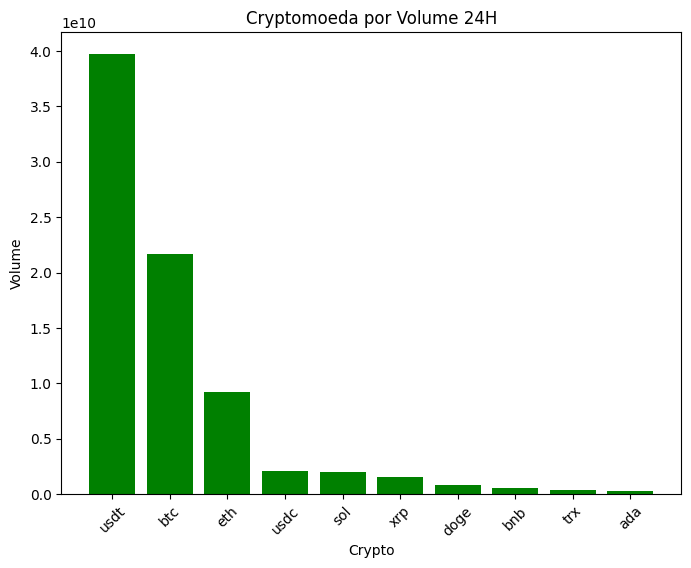

In [13]:
plt.figure(figsize=(8,6))
plt.bar(top_vol.index, top_vol.values, color='green')
plt.title('Cryptomoeda por Volume 24H')
plt.xlabel('Crypto')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.show()

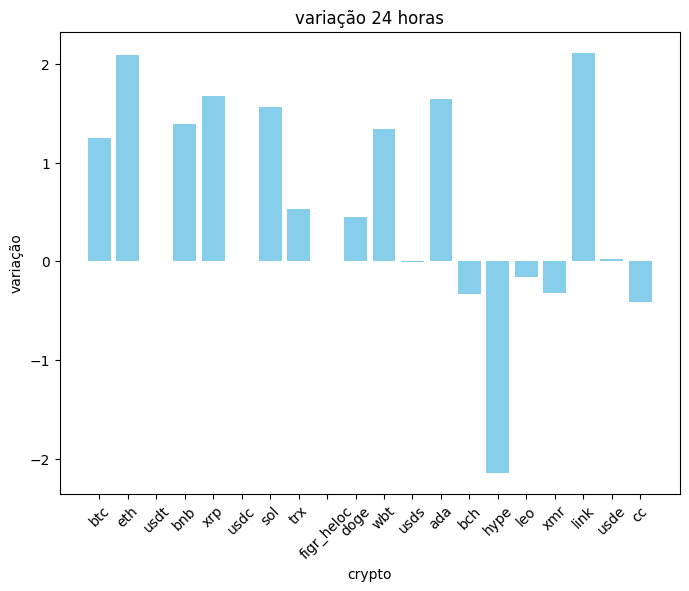

In [14]:
plt.figure(figsize=(8,6))
plt.bar(df['symbol'],df['price_change_percentage_24h'], color='skyblue')
plt.title('variação 24 horas')
plt.xlabel('crypto')
plt.ylabel('variação')
plt.xticks(rotation=45)
plt.show()